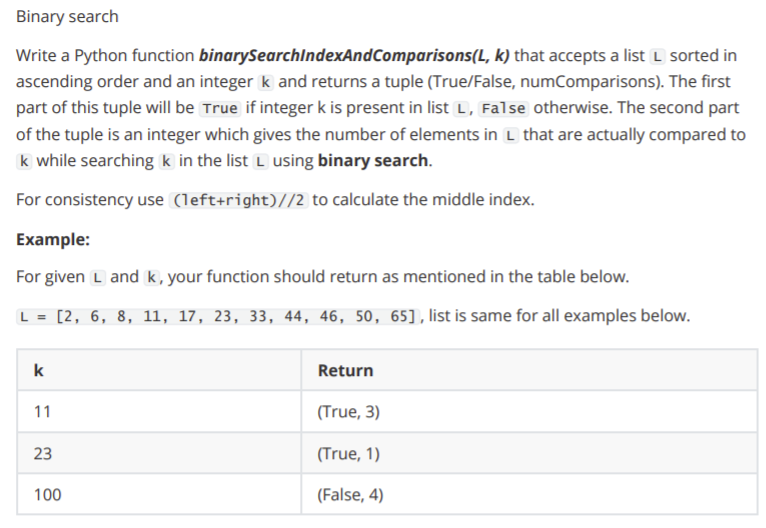

In [ ]:
def binarySearchIndexAndComparisons(L:list,k:int):
    L=mergeSort(L)
    binarySearch(L,k)
def binarySearch(L:list,k:int):
    m=len(L)//2
    if k==L[m]:
        return True
    if k<L[m]:
        return BinarySearch(L[:m],k)
    if k>L[m]:
        return binarySearch(L[m+1:],k)
    
def mergeSort(A:list):
    n=len(A)
    if n<=1:
        return A
    L=mergeSort(A[:n//2])
    R=mergeSort(A[n//2:])
    B=merge(L,R)
    return B
def merge(A,B):
    (m,n)=(len(A),len(B))
    (C,i,j,k)=([],0,0,0)
    while k<m+n:
        if i==m:
            C.extend(B[j:])
        elif j==n:
            C.extend(A[i:])
            k+=n-i
        elif A[i]<B[j]:
            C.append(A[i])
            (i,k)=(i+1,k+1)
        else:
            C.append(B[j])
            (j,k)=(j+1,k+1)
            return C

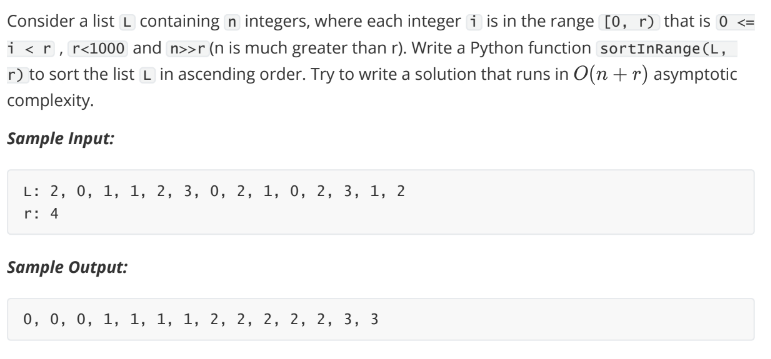

In [ ]:
def sortInRange(L:list,r:int)->list:
    n=len(L)
    if n<=1:
        return L
    Left=sortInRange(L[:n//2],r)
    Right=sortInRange(L[n//2:],r)
    B=merge(Left,Right)
    return B
def merge(A,B):
    (m,n)=(len(A),len(B))
    (C,i,j,k)=([],0,0,0)
    while k<m+n:
        if i==m:
            C.extend(B[j:])
            k+=n-j
        elif j==n:
            C.extend(A[i:])
            k+=n-i
        elif A[i]<B[j]:
            C.append(A[i])
            (i,k)=(i+1,k+1)
        else:
            C.append(B[j])
            (j,k)=(j+1,k+1)
    return C

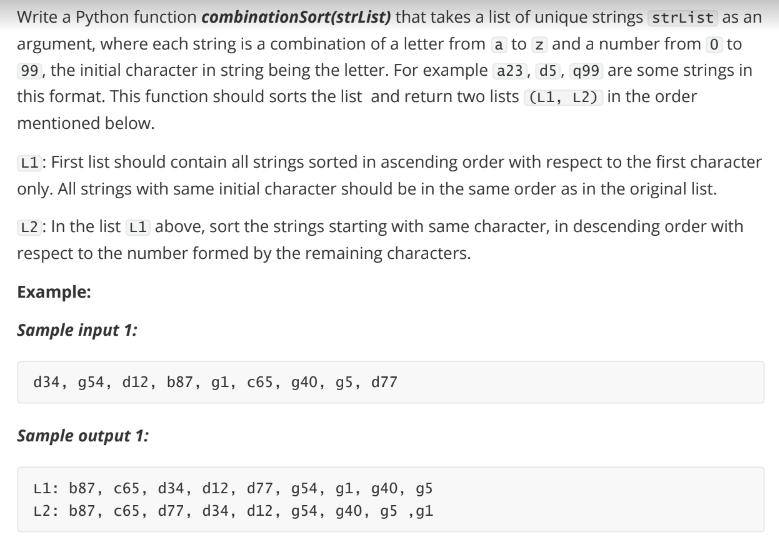

In [ ]:
'''Starting from here, I have to do it from myself'''
import re
from typing import List, Tuple

def combinationSort(strList: List[str]) -> Tuple[List[str], List[str]]:
    """
    Takes a list of unique strings (each a letter followed by a number 0-99)
    and returns two sorted lists, L1 and L2.

    Args:
        strList: The original list of strings. E.g., ['d34', 'g54', 'd12', 'b87', 'g1']

    Returns:
        A tuple (L1, L2) containing the two sorted lists.
    """

    # --- Helper Key Functions ---

    def l1_sort_key(s: str) -> str:
        """Key for L1: Sort by the first character (letter)."""
        return s[0]

    def l2_sort_key(s: str) -> Tuple[str, int]:
        """
        Key for L2: Multi-level sort.
        1. Primary: Sort by the letter (s[0]) in ascending order.
        2. Secondary: Sort by the number (s[1:]) in descending order.

        To achieve descending order for the number while using Python's default
        ascending sort, we return the negative of the number.
        """
        letter = s[0]
        # Convert the rest of the string to an integer
        try:
            number = int(s[1:])
        except ValueError:
            # Handle cases where the number part might be missing or invalid,
            # though the problem states the format is guaranteed.
            print(f"Warning: String '{s}' does not match expected format.")
            number = 0

        # We return (letter, -number). When Python sorts this tuple:
        # - It compares letters (ascending).
        # - If letters are equal, it compares -number.
        # - -77 is smaller than -34, so a string with 77 comes before one with 34.
        return (letter, -number)

    # --- L1: Letter Ascending, Original Order Preserved (Stable Sort) ---

    # Python's built-in sorted() is a Timsort implementation, which is stable.
    # Sorting only by the letter naturally preserves the original relative
    # order of strings that have the same initial letter.
    L1 = sorted(strList, key=l1_sort_key)


    # --- L2: Letter Ascending, Number Descending (Multi-Key Sort) ---

    # This single sort handles both criteria: primary by letter (ascending),
    # secondary by number (descending via the negative sign).
    L2 = sorted(strList, key=l2_sort_key)

    return (L1, L2)
